In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
from pathlib import Path
from os import environ
import os
import os

ROOT = Path(f"{Path.cwd().parents[1]}/outputs")
basedir = Path(f"{ROOT}/mixture/binom2d")
datadir = Path(f"{basedir}/data")
outputdir = Path(f"{basedir}/wbic-bias")

if not outputdir.exists():
  outputdir.mkdir(exist_ok=True)
  print(f"Created {outputdir}!")

print(f"Using datadir={datadir}")
print(f"Using outputdir={outputdir}")

dry = False # whether or not to save results

Using datadir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/binom2d/data
Using outputdir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/binom2d/wbic-bias


In [4]:
import pandas as pd

dgps_file = f"{datadir}/dgp.csv"
dgps=pd.read_csv(dgps_file, index_col=0).reset_index()
dgps.head()

,dsid,p0,p1,w0,w1
0,regular,0.15,0.35,0.75,0.25
1,e-singular,0.25,0.35,0.75,0.25
2,singular1,0.15,0.35,1.00,0.00
3,singular2,0.35,0.35,0.75,0.25


In [5]:
def find_truth_by_dsid(dsid: str):
  dgp = dgps.query(f"dsid=='{dsid}'")
  truth = dgp[["p0", "p1", "w0", "w1"]].iloc[0].tolist()
  return truth

In [6]:
wbic_df = pd.read_csv(f"{outputdir}/fe_by_ti.csv")
wbic_df.head()

,dsid,regime,n,trial,wbic,fe,chains,draws,tune,mean_divergences,total_divergences,max_divergences,divergences_per_chain,chain_tree_depth,n_components
0,regular,50,50,0,166.973538,169.480808,1,1000,2500,0.0,0,0,[0],5,2
1,e-singular,50,50,0,160.859504,162.214551,1,1000,2500,0.0,0,0,[0],7,2
2,singular1,50,50,0,143.926150,145.520635,1,1000,2500,0.0,0,0,[0],8,2
3,singular2,50,50,0,153.828493,155.222949,1,1000,2500,0.0,0,0,[0],8,2
4,regular,250,250,0,842.389216,844.913288,1,1000,2500,0.0,0,0,[0],5,2


In [18]:
# Prep data
wbic_df['error'] = wbic_df['wbic'] - wbic_df['fe']
wbic_df['normalized_error'] = (wbic_df['wbic'] - wbic_df['fe'])/np.log(wbic_df['fe'])
wbic_df['Model'] = wbic_df['n_components'].map({2: 'K=2', 3: 'K=3', 5: 'K=5'})
len(wbic_df["trial"].unique())

21

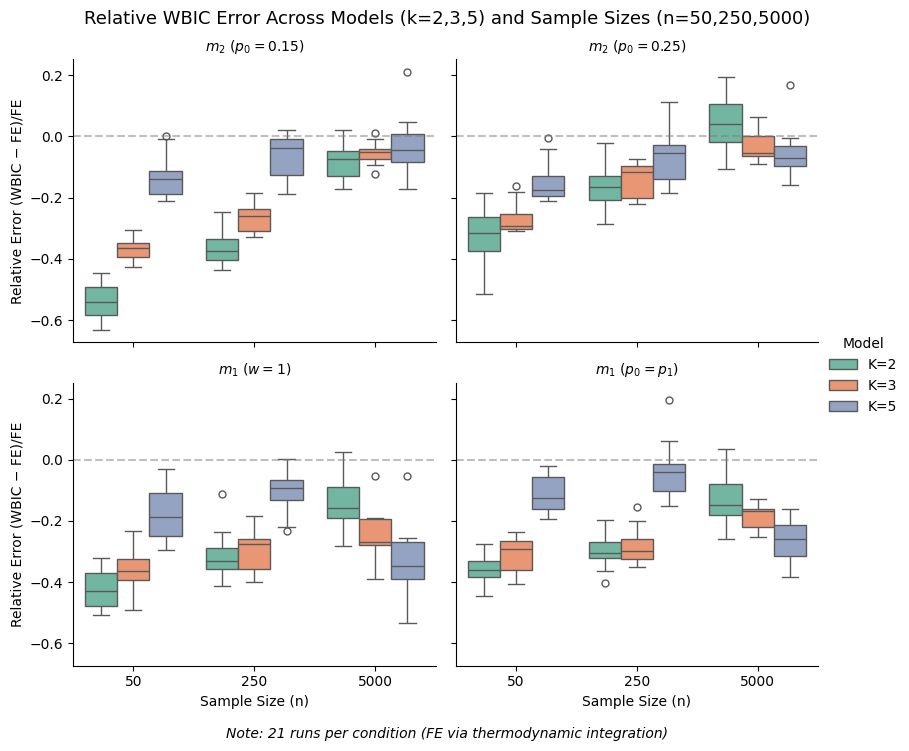

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Create mapping with LaTeX
dsid_labels = {
  "regular": r"$m_2$ ($p_0=0.15$)",
  "e-singular": r"$m_2$ ($p_0=0.25$)",
  "singular1": r"$m_1$ ($w=1$)",
  "singular2": r"$m_1$ ($p_0=p_1$)"
}

# Add display column
wbic_df["dgp_label"] = wbic_df["dsid"].map(dsid_labels)
# Box plot using catplot with shared y-axis
g = sns.catplot(
    data=wbic_df,
    x='n',
    y='normalized_error',
    hue='Model',
    col='dgp_label',
    kind='box',
    col_wrap=2,
    sharey=True,
    height=3.5,
    aspect=1.2,
    palette='Set2'
)

# Add reference line at 0
for ax in g.axes.flat:
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)

g.set_axis_labels('Sample Size (n)', 'Relative Error (WBIC − FE)/FE')
g.set_titles(col_template='{col_name}')
g.figure.suptitle('Relative WBIC Error Across Models (k=2,3,5) and Sample Sizes (n=50,250,5000)', fontsize=13, y=1.02)
g.figure.text(0.5, -0.02, 'Note: 21 runs per condition (FE via thermodynamic integration)', 
              ha='center', fontsize=10, style='italic')

# plt.tight_layout()
plt.savefig('wbic_error_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

Estimated convergence rates (RMSE ~ n^(-α)):
      dsid Model     alpha  intercept  r_squared
e-singular   K=2  0.129522   0.965562   0.931986
e-singular   K=3  0.200213   1.118897   0.998947
e-singular   K=5 -0.031401  -0.383541   0.474849
   regular   K=2  0.243237   2.080788   0.939670
   regular   K=3  0.253080   1.778956   0.907859
   regular   K=5 -0.072409  -0.671400   0.489175
 singular1   K=2  0.074606   1.085399   0.862613
 singular1   K=3 -0.064623   0.322695   0.998043
 singular1   K=5 -0.288333  -1.394454   0.789471
 singular2   K=2  0.049737   0.854539   0.630751
 singular2   K=3 -0.021830   0.439771   0.345475
 singular2   K=5 -0.323724  -1.889906   0.911075


KeyError: 'K=5'

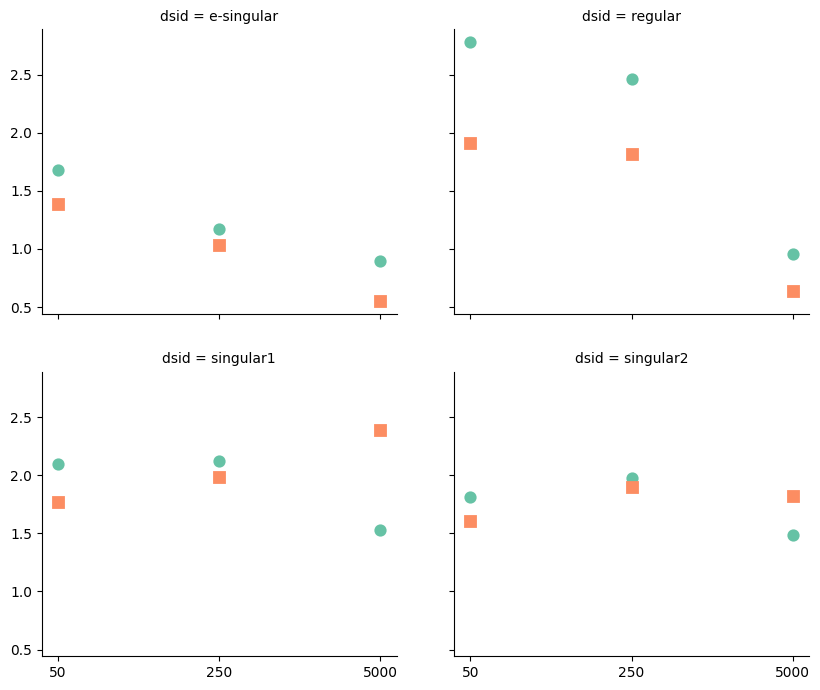

In [9]:
from scipy import stats

# Aggregate: RMSE per (dsid, n, model)
summary = wbic_df.groupby(['dsid', 'n', 'Model']).agg(
    rmse=('error', lambda x: np.sqrt(np.mean(x**2)))
).reset_index()

# Log transform for regression
summary['log_n'] = np.log(summary['n'])
summary['log_rmse'] = np.log(summary['rmse'])

# Fit convergence rate for each (dsid, Model)
def fit_rate(group):
    slope, intercept, r, p, se = stats.linregress(group['log_n'], group['log_rmse'])
    return pd.Series({
        'alpha': -slope,
        'intercept': intercept,
        'r_squared': r**2
    })

rates = summary.groupby(['dsid', 'Model']).apply(fit_rate).reset_index()
print("Estimated convergence rates (RMSE ~ n^(-α)):")
print(rates.to_string(index=False))

# Plot using relplot (continuous x-axis)
g = sns.relplot(
    data=summary,
    x='n',
    y='rmse',
    hue='Model',
    col='dsid',
    kind='scatter',
    col_wrap=2,
    height=3.5,
    aspect=1.2,
    palette='Set2',
    s=80
)

# Add fitted convergence lines
for ax, dsid in zip(g.axes.flat, summary['dsid'].unique()):
    subset = summary[summary['dsid'] == dsid]
    n_vals = sorted(subset['n'].unique())
    n_range = np.linspace(min(n_vals), max(n_vals), 100)
    
    for model, color in zip(['K=2', 'K=3', 'K=5'], sns.color_palette('Set2')):
        rate_row = rates[(rates['dsid'] == dsid) & (rates['Model'] == model)]
        if len(rate_row) == 0:
            continue
        alpha = rate_row['alpha'].values[0]
        intercept = rate_row['intercept'].values[0]
        
        fitted = np.exp(intercept) * n_range ** (-alpha)
        ax.plot(n_range, fitted, color=color, linestyle='--', alpha=0.7,
                label=f'{model}: α={alpha:.2f}')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend(fontsize=8)

g.set_axis_labels('Sample Size (n)', 'RMSE')
g.set_titles(col_template='{col_name}')

plt.tight_layout()
plt.show()

print("\nConvergence rates summary:")
pivot = rates.pivot(index='dsid', columns='Model', values='alpha')
print(pivot.round(3))